# RAG-eval comparison — phase 1/2/3

Reads all finished runs from the `pytorch-rag-eval` wandb project and produces side-by-side comparisons for the experiment matrix designed in `eval-runner/README.md`.

**Layout:**
1. Load runs → flat DataFrame
2. Phase 1 story-line (vanilla → rerank → qt → lora) — bar plots
3. Phase 2 sensitivity sweeps (top_k, fetch_k, temperature) — line + bar plots
4. Phase 3 stability (3 seeds) — mean ± std error bars
5. Latency comparison (rag vs pure baseline)
6. Summary table (top runs by composite `score/rag_score`)

Re-run the whole notebook after new wandb runs appear to refresh charts.

## 1. Setup

In [1]:
!pip install matplotlib numpy pandas

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from eval_runner.wandb_loader import fetch_runs_as_df, has_tag

PROJECT = "pytorch-rag-eval"
ENTITY = "ooovotetoda"  # change if you log to a different wandb entity

# Common metric groups we plot repeatedly
RAGAS_METRICS = ["ragas/faithfulness", "ragas/answer_relevancy", "ragas/context_recall"]
LEXICAL_METRICS = ["lexical/rag_f1", "lexical/pure_f1"]
STORY_METRICS = [
    "lexical/rag_f1",
    "ragas/faithfulness",
    "ragas/answer_relevancy",
    "ragas/context_recall",
    "score/rag_score",
]

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "axes.grid.axis": "y"})

/Users/yuga/Projects/Python/HSE-RAG/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
df = fetch_runs_as_df(PROJECT, entity=ENTITY)
print(f"loaded {len(df)} finished runs (excluding _sanity-*)")
df[["run_name", "tags", "score/rag_score"]].head(20)

wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from /Users/yuga/.netrc.


loaded 11 finished runs (excluding _sanity-*)


,run_name,tags,score/rag_score
0,base-qt-k5,"[base, phase:1, qt, story]",0.506827
1,base-rerank-k5,"[base, phase:1, rerank, story]",0.530473
2,base-vanilla-k5,"[base, phase:1, story, vanilla]",0.547989
3,lora-rerank-k10,"[lora, phase:2, rerank, sweep:topk]",0.281392
4,lora-rerank-k3,"[lora, phase:2, rerank, sweep:topk]",0.250393
5,lora-rerank-k5,"[lora, main, phase:1, rerank, story]",0.292983
6,lora-rerank-k5-fetch10,"[lora, phase:2, rerank, sweep:fetchk]",0.275964
7,lora-rerank-k5-fetch50,"[lora, phase:2, rerank, sweep:fetchk]",0.284384
8,lora-rerank-k5-seed43,"[lora, phase:3, rerank, stability]",0.287658
9,lora-rerank-k5-seed44,"[lora, phase:3, rerank, stability]",0.263586


In [4]:
# Quick sanity — make sure all expected runs are here. Warn if anything missing.
EXPECTED = {
    "base-vanilla-k5", "base-rerank-k5", "base-qt-k5",
    "lora-rerank-k5", "lora-rerank-k3", "lora-rerank-k10",
    "lora-rerank-k5-fetch10", "lora-rerank-k5-fetch50",
    "lora-rerank-k5-temp0", "lora-rerank-k5-seed43", "lora-rerank-k5-seed44",
}
have = set(df["run_name"])
missing = EXPECTED - have
extra = have - EXPECTED
if missing:
    print(f"MISSING runs: {sorted(missing)}")
if extra:
    print(f"extra runs (not in matrix): {sorted(extra)}")
if not missing and not extra:
    print("all 11 matrix runs present, no surprises")

all 11 matrix runs present, no surprises


## 2. Phase 1 — story-line bars

Each new technique in chronological order. Want to see each bar taller than the previous on the metrics that matter (faithfulness, rag_score).

- `base-vanilla-k5` — minimal RAG
- `base-rerank-k5` — + cross-encoder rerank
- `base-qt-k5` — + query rewriting + HyDE
- `lora-rerank-k5` — base swapped for our LoRA-finetuned model

In [5]:
PHASE1_ORDER = ["base-vanilla-k5", "base-rerank-k5", "base-qt-k5", "lora-rerank-k5"]
phase1 = df.set_index("run_name").reindex(PHASE1_ORDER)
phase1[STORY_METRICS]

,lexical/rag_f1,ragas/faithfulness,ragas/answer_relevancy,ragas/context_recall,score/rag_score
run_name,,,,,
base-vanilla-k5,0.253499,0.302507,0.756768,0.621396,0.547989
base-rerank-k5,0.256596,0.248205,0.767499,0.620955,0.530473
base-qt-k5,0.247931,0.205049,0.745279,0.633477,0.506827
lora-rerank-k5,0.104765,0.276283,0.155773,0.600803,0.292983


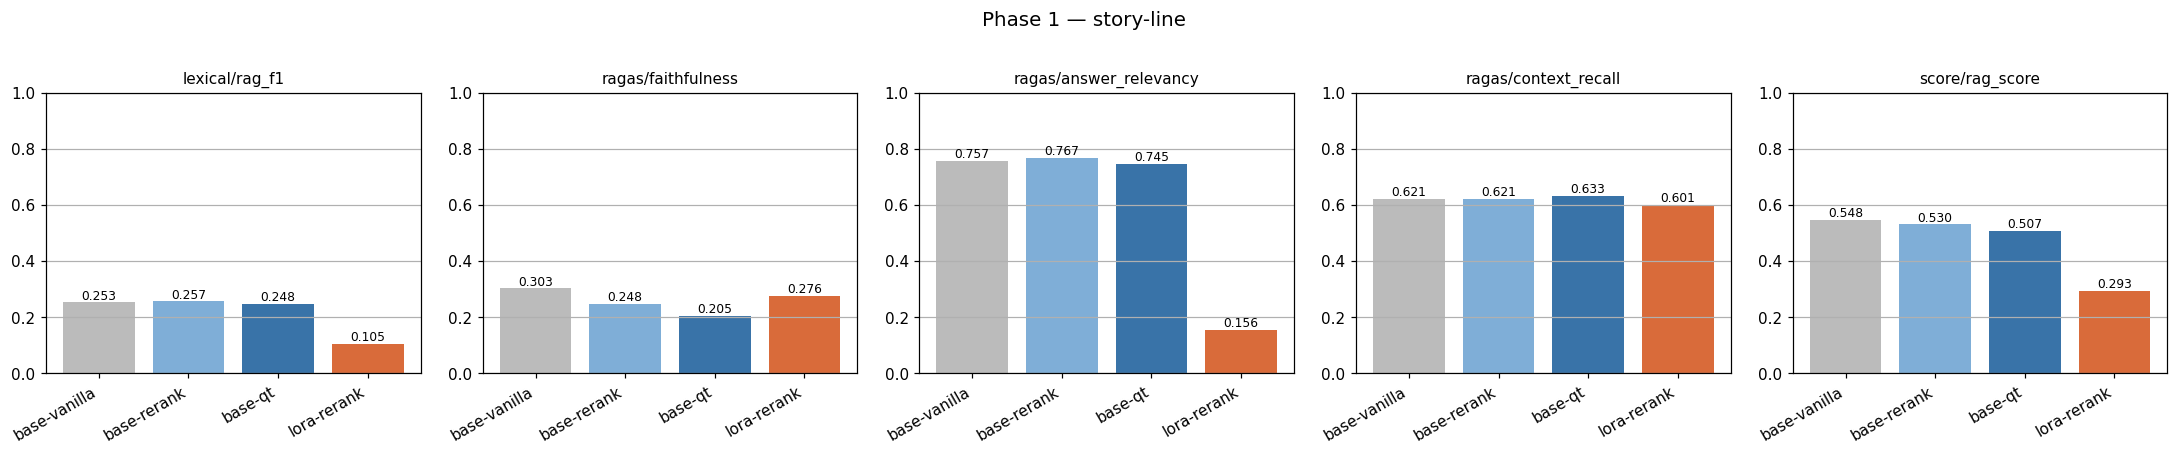

In [6]:
fig, axes = plt.subplots(1, len(STORY_METRICS), figsize=(4 * len(STORY_METRICS), 4), sharey=False)
colors = ["#bbbbbb", "#7faed7", "#3973a8", "#d96b3a"]  # last bar (lora) highlighted
for ax, metric in zip(axes, STORY_METRICS):
    vals = phase1[metric]
    ax.bar(range(len(vals)), vals.values, color=colors)
    ax.set_xticks(range(len(vals)))
    ax.set_xticklabels([n.replace("-k5", "") for n in vals.index], rotation=30, ha="right")
    ax.set_title(metric, fontsize=10)
    ax.set_ylim(0, max(1.0, vals.max() * 1.15))
    for i, v in enumerate(vals.values):
        if pd.notna(v):
            ax.text(i, v, f"{v:.3f}", ha="center", va="bottom", fontsize=8)
fig.suptitle("Phase 1 — story-line", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 3. Phase 2 — sensitivity sweeps

Hold all knobs constant except one to isolate its effect on metrics.

### 3.1 `top_k` sweep (3 / 5 / 10)

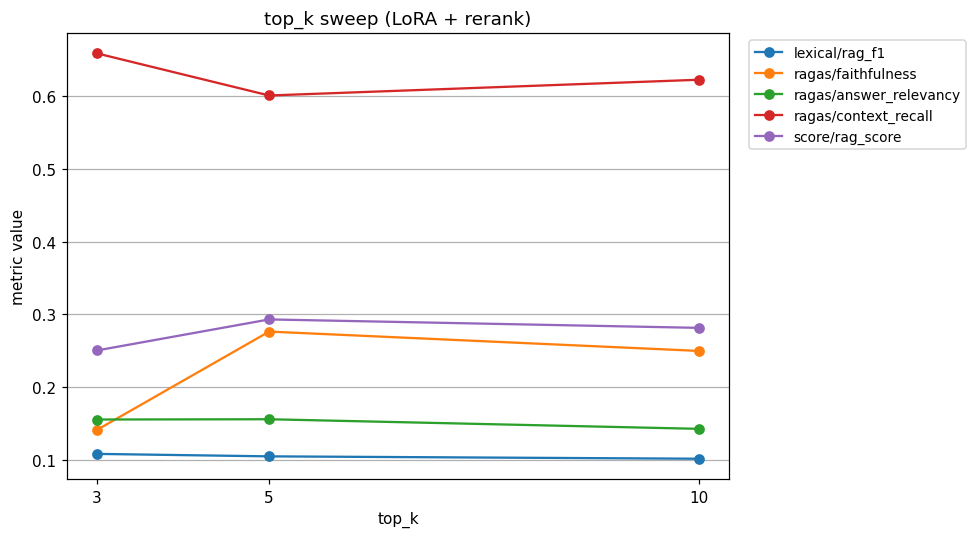

,cfg.top_k,lexical/rag_f1,ragas/faithfulness,ragas/answer_relevancy,ragas/context_recall,score/rag_score
run_name,,,,,,
lora-rerank-k3,3,0.108162,0.141260,0.155411,0.658624,0.250393
lora-rerank-k5,5,0.104765,0.276283,0.155773,0.600803,0.292983
lora-rerank-k10,10,0.101507,0.249669,0.142582,0.622457,0.281392


In [7]:
TOPK_RUNS = ["lora-rerank-k3", "lora-rerank-k5", "lora-rerank-k10"]
sweep_k = df.set_index("run_name").reindex(TOPK_RUNS).sort_values("cfg.top_k")

fig, ax = plt.subplots(figsize=(9, 5))
for m in STORY_METRICS:
    ax.plot(sweep_k["cfg.top_k"], sweep_k[m], marker="o", label=m)
ax.set_xlabel("top_k")
ax.set_ylabel("metric value")
ax.set_xticks(sweep_k["cfg.top_k"].astype(int).tolist())
ax.set_title("top_k sweep (LoRA + rerank)")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9)
plt.tight_layout()
plt.show()

sweep_k[["cfg.top_k", *STORY_METRICS]]

### 3.2 `fetch_k` sweep (10 / 20 / 50)

`top_k=5` constant, but the number of candidates the cross-encoder reranks varies.

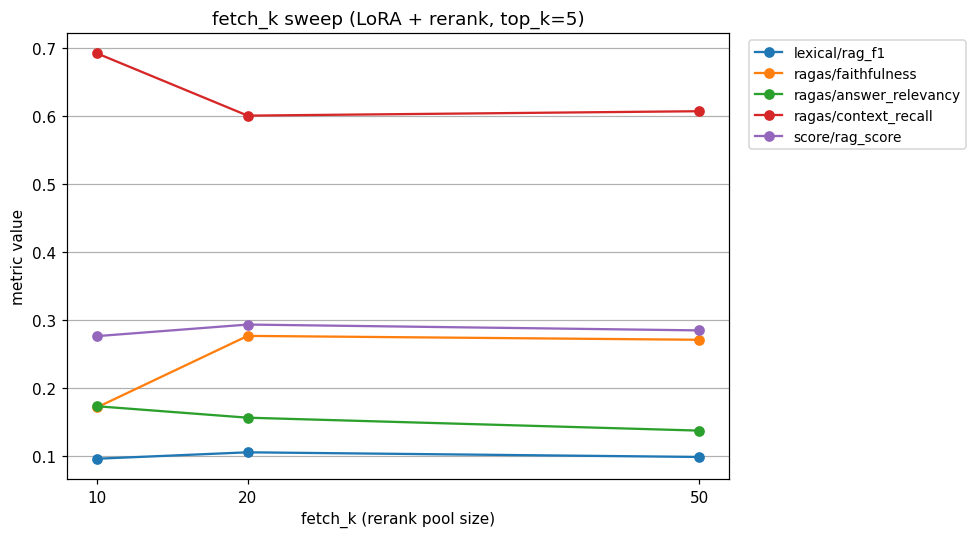

,cfg.fetch_k,lexical/rag_f1,ragas/faithfulness,ragas/answer_relevancy,ragas/context_recall,score/rag_score
run_name,,,,,,
lora-rerank-k5-fetch10,10,0.095309,0.171074,0.172617,0.692439,0.275964
lora-rerank-k5,20,0.104765,0.276283,0.155773,0.600803,0.292983
lora-rerank-k5-fetch50,50,0.097907,0.270568,0.136737,0.607311,0.284384


In [8]:
FETCH_RUNS = ["lora-rerank-k5-fetch10", "lora-rerank-k5", "lora-rerank-k5-fetch50"]
sweep_fetch = df.set_index("run_name").reindex(FETCH_RUNS).sort_values("cfg.fetch_k")

fig, ax = plt.subplots(figsize=(9, 5))
for m in STORY_METRICS:
    ax.plot(sweep_fetch["cfg.fetch_k"], sweep_fetch[m], marker="o", label=m)
ax.set_xlabel("fetch_k (rerank pool size)")
ax.set_ylabel("metric value")
ax.set_xticks(sweep_fetch["cfg.fetch_k"].astype(int).tolist())
ax.set_title("fetch_k sweep (LoRA + rerank, top_k=5)")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9)
plt.tight_layout()
plt.show()

sweep_fetch[["cfg.fetch_k", *STORY_METRICS]]

### 3.3 Temperature comparison (0.0 vs 0.1)

Does deterministic decoding (temp=0) outperform default temp=0.1?

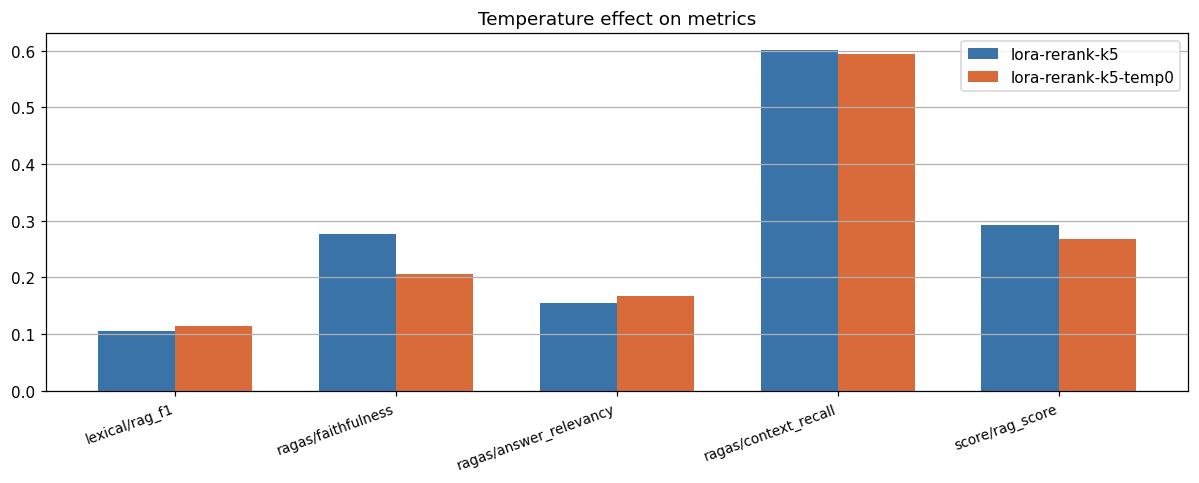

,cfg.llm_temperature,lexical/rag_f1,ragas/faithfulness,ragas/answer_relevancy,ragas/context_recall,score/rag_score
run_name,,,,,,
lora-rerank-k5,0.1,0.104765,0.276283,0.155773,0.600803,0.292983
lora-rerank-k5-temp0,0.0,0.113803,0.205644,0.167857,0.594083,0.268217


In [9]:
TEMP_RUNS = ["lora-rerank-k5", "lora-rerank-k5-temp0"]
temp_df = df.set_index("run_name").reindex(TEMP_RUNS)

x = np.arange(len(STORY_METRICS))
width = 0.35
fig, ax = plt.subplots(figsize=(11, 4.5))
for i, (name, color) in enumerate(zip(TEMP_RUNS, ["#3973a8", "#d96b3a"])):
    vals = temp_df.loc[name, STORY_METRICS]
    ax.bar(x + (i - 0.5) * width, vals.values, width, label=name, color=color)
ax.set_xticks(x)
ax.set_xticklabels(STORY_METRICS, rotation=20, ha="right", fontsize=9)
ax.set_title("Temperature effect on metrics")
ax.legend()
plt.tight_layout()
plt.show()

temp_df[["cfg.llm_temperature", *STORY_METRICS]]

## 4. Phase 3 — stability across seeds

Same config, three different `eval_seed` values (42, 43, 44). The error bars show variance from sample selection — if huge, single-run results aren't trustworthy and the matrix needs more runs / larger sample.

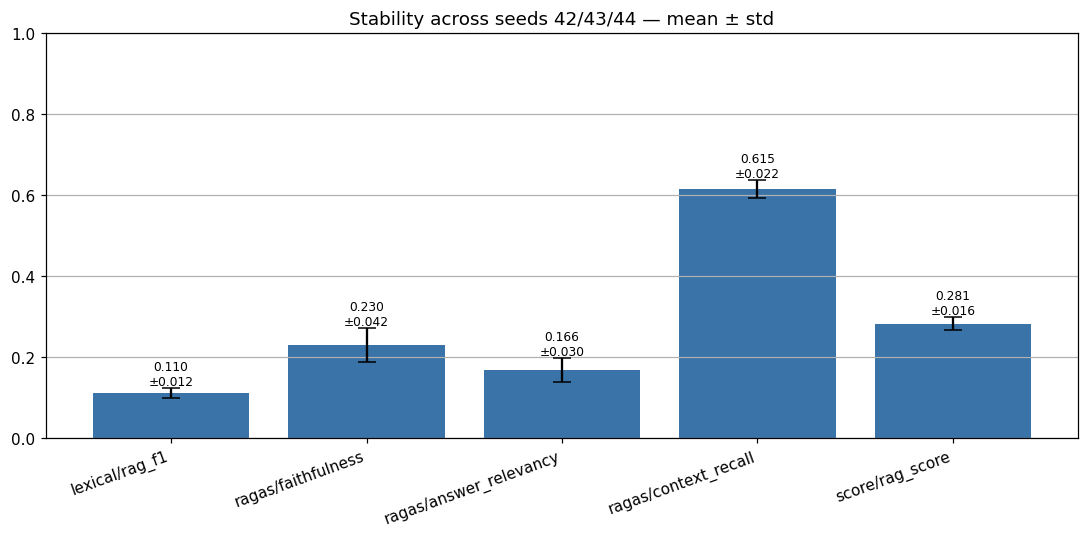

,mean,std,cv_%
lexical/rag_f1,0.109840,0.011799,10.7
ragas/faithfulness,0.229689,0.041871,18.2
ragas/answer_relevancy,0.166290,0.029528,17.8
ragas/context_recall,0.615089,0.022133,3.6
score/rag_score,0.281409,0.015663,5.6


In [10]:
SEED_RUNS = ["lora-rerank-k5", "lora-rerank-k5-seed43", "lora-rerank-k5-seed44"]
seeds = df.set_index("run_name").reindex(SEED_RUNS)

means = seeds[STORY_METRICS].mean()
stds = seeds[STORY_METRICS].std()

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(range(len(STORY_METRICS)), means.values, yerr=stds.values, capsize=6, color="#3973a8")
ax.set_xticks(range(len(STORY_METRICS)))
ax.set_xticklabels(STORY_METRICS, rotation=20, ha="right")
ax.set_title("Stability across seeds 42/43/44 — mean ± std")
for i, (m, s) in enumerate(zip(means.values, stds.values)):
    ax.text(i, m + s, f"{m:.3f}\n±{s:.3f}", ha="center", va="bottom", fontsize=8)
ax.set_ylim(0, max(1.0, (means + stds).max() * 1.2))
plt.tight_layout()
plt.show()

pd.DataFrame({"mean": means, "std": stds, "cv_%": (stds / means * 100).round(1)})

## 5. Latency — RAG vs pure baseline

RAG always slower because of retrieval and longer prompts. Useful to see the cost in seconds per query.

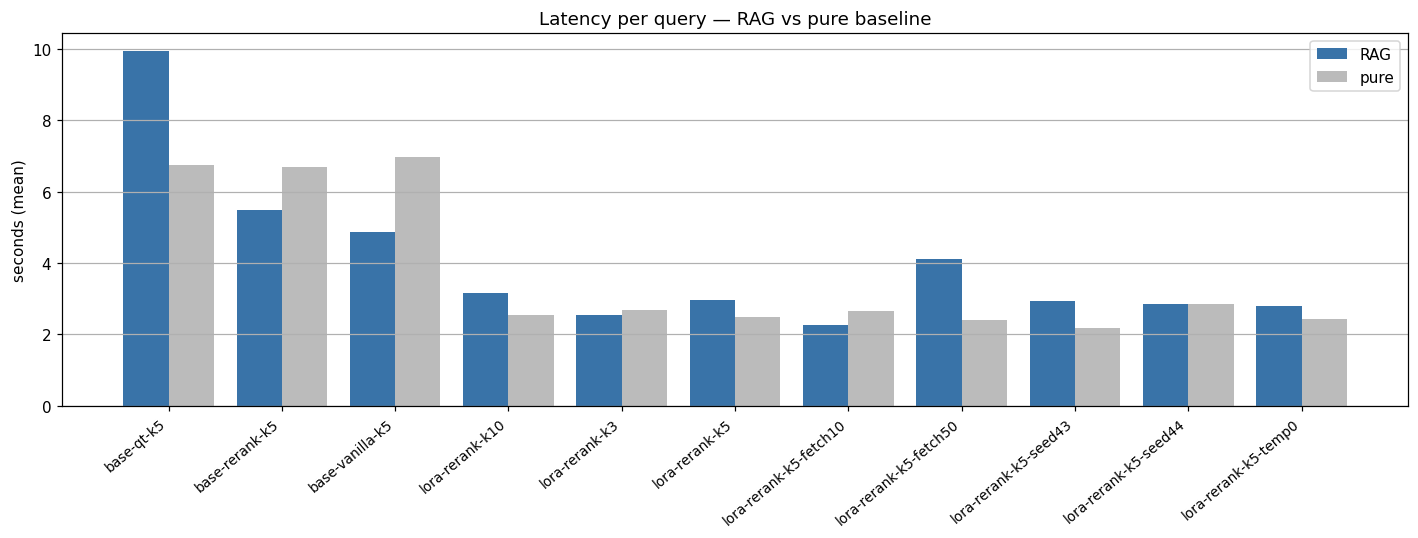

,latency/rag_mean_s,latency/pure_mean_s
run_name,,
base-qt-k5,9.94,6.74
base-rerank-k5,5.49,6.69
base-vanilla-k5,4.86,6.96
lora-rerank-k10,3.15,2.55
lora-rerank-k3,2.54,2.68
lora-rerank-k5,2.97,2.50
lora-rerank-k5-fetch10,2.25,2.67
lora-rerank-k5-fetch50,4.11,2.39
lora-rerank-k5-seed43,2.94,2.17


In [11]:
lat_cols = ["latency/rag_mean_s", "latency/pure_mean_s"]
lat_df = df.set_index("run_name")[lat_cols].sort_index()

fig, ax = plt.subplots(figsize=(13, 5))
x = np.arange(len(lat_df))
width = 0.4
ax.bar(x - width / 2, lat_df["latency/rag_mean_s"], width, label="RAG", color="#3973a8")
ax.bar(x + width / 2, lat_df["latency/pure_mean_s"], width, label="pure", color="#bbbbbb")
ax.set_xticks(x)
ax.set_xticklabels(lat_df.index, rotation=40, ha="right", fontsize=9)
ax.set_ylabel("seconds (mean)")
ax.set_title("Latency per query — RAG vs pure baseline")
ax.legend()
plt.tight_layout()
plt.show()

lat_df.round(2)

## 6. Summary table — top runs by composite score

Quick sort by `score/rag_score` to identify the headline winner. Useful when picking which config to ship.

In [12]:
summary_cols = [
    "run_name",
    "score/rag_score",
    "ragas/faithfulness",
    "ragas/answer_relevancy",
    "ragas/context_recall",
    "lexical/rag_f1",
    "lexical/pure_f1",
    "semantic/answer_similarity",
    "latency/rag_mean_s",
]
top = (
    df.sort_values("score/rag_score", ascending=False)
    .loc[:, [c for c in summary_cols if c in df.columns]]
    .reset_index(drop=True)
)
top.round(3).head(15)

,run_name,score/rag_score,ragas/faithfulness,ragas/answer_relevancy,ragas/context_recall,lexical/rag_f1,lexical/pure_f1,semantic/answer_similarity,latency/rag_mean_s
0,base-vanilla-k5,0.548,0.303,0.757,0.621,0.253,0.236,0.884,4.865
1,base-rerank-k5,0.530,0.248,0.767,0.621,0.257,0.241,0.886,5.485
2,base-qt-k5,0.507,0.205,0.745,0.633,0.248,0.239,0.881,9.944
3,lora-rerank-k5,0.293,0.276,0.156,0.601,0.105,0.210,0.562,2.967
4,lora-rerank-k5-seed43,0.288,0.218,0.200,0.604,0.123,0.225,0.602,2.935
5,lora-rerank-k5-fetch50,0.284,0.271,0.137,0.607,0.098,0.221,0.530,4.114
6,lora-rerank-k10,0.281,0.250,0.143,0.622,0.102,0.226,0.548,3.154
7,lora-rerank-k5-fetch10,0.276,0.171,0.173,0.692,0.095,0.216,0.557,2.250
8,lora-rerank-k5-temp0,0.268,0.206,0.168,0.594,0.114,0.213,0.571,2.790
9,lora-rerank-k5-seed44,0.264,0.195,0.143,0.641,0.101,0.210,0.569,2.839


## 7. (Optional) RAG vs Pure win-rate

From the lexical metric: in how many sampled questions did RAG beat the pure-LLM baseline? Higher is better for `rag_better_count`.

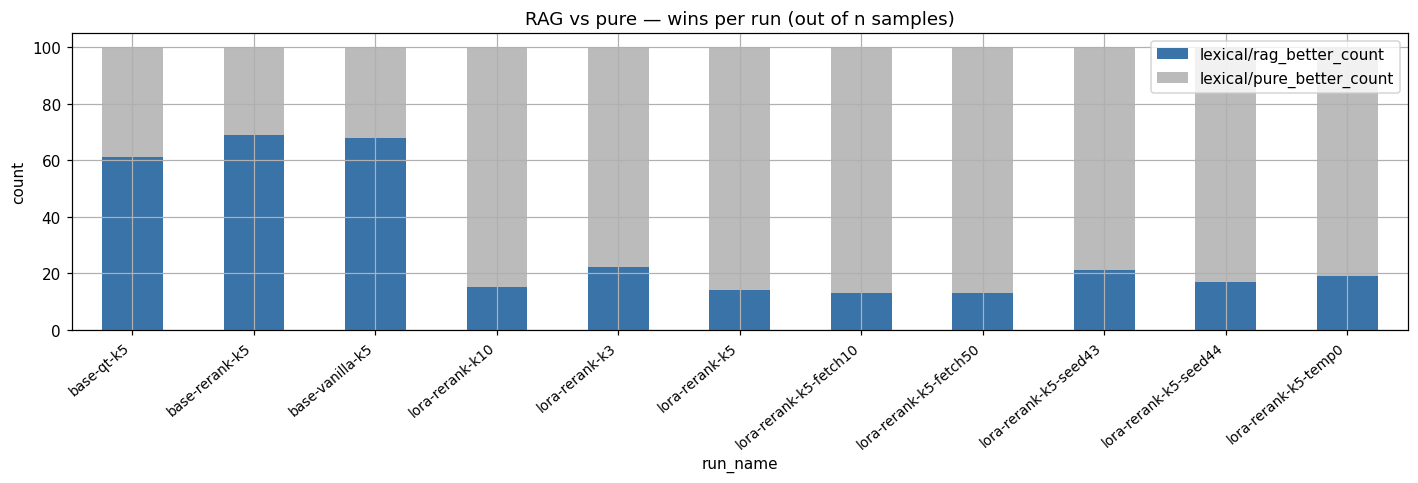

In [13]:
win_cols = ["lexical/rag_better_count", "lexical/pure_better_count"]
if all(c in df.columns for c in win_cols):
    win = df.set_index("run_name")[win_cols].sort_index()
    win.plot.bar(stacked=True, figsize=(13, 4.5), color=["#3973a8", "#bbbbbb"])
    plt.title("RAG vs pure — wins per run (out of n samples)")
    plt.xticks(rotation=40, ha="right", fontsize=9)
    plt.ylabel("count")
    plt.tight_layout()
    plt.show()
    win
else:
    print("win-rate columns not present in fetched runs")